In [ ]:
model_results = pd.DataFrame([
    {
        "model": baseline_result["model"],
        "best_val_accuracy": baseline_result["best_val_accuracy"],
        "test_accuracy": baseline_result["test_accuracy"],
        "test_macro_f1": baseline_result["test_macro_f1"],
        "test_weighted_f1": baseline_result["test_weighted_f1"],
    },
    {
        "model": bn_result["model"],
        "best_val_accuracy": bn_result["best_val_accuracy"],
        "test_accuracy": bn_result["test_accuracy"],
        "test_macro_f1": bn_result["test_macro_f1"],
        "test_weighted_f1": bn_result["test_weighted_f1"],
    },
    {
        "model": vgg_result["model"],
        "best_val_accuracy": vgg_result["best_val_accuracy"],
        "test_accuracy": vgg_result["test_accuracy"],
        "test_macro_f1": vgg_result["test_macro_f1"],
        "test_weighted_f1": vgg_result["test_weighted_f1"],
    },
])

model_results = model_results.sort_values("test_macro_f1", ascending=False)
model_results

,model,best_val_accuracy,test_accuracy,test_macro_f1,test_weighted_f1
2,VGG16 Transfer Learning,0.869266,0.877707,0.907879,0.876804
1,CNN + BatchNorm + Dropout,0.759748,0.779618,0.809925,0.779379
0,Baseline CNN,0.723050,0.740127,0.756094,0.739652


In [ ]:
comparison_path = REPORTS_DIR / "model_comparison.csv"
model_results.to_csv(comparison_path, index=False, encoding="utf-8-sig")
print("Model comparison saved to:", comparison_path)

Model comparison saved to: /content/drive/MyDrive/car_damage_project/reports/model_comparison.csv


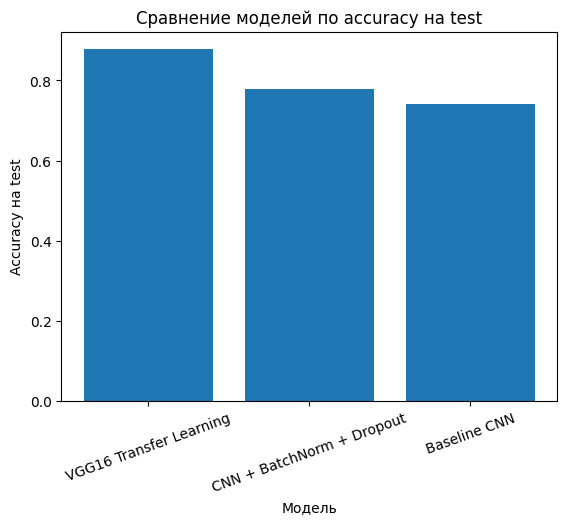

In [ ]:
plt.bar(model_results["model"], model_results["test_accuracy"])
plt.title("Сравнение моделей по accuracy на test")
plt.xlabel("Модель")
plt.ylabel("Accuracy на test")
plt.xticks(rotation=20)
plt.show()

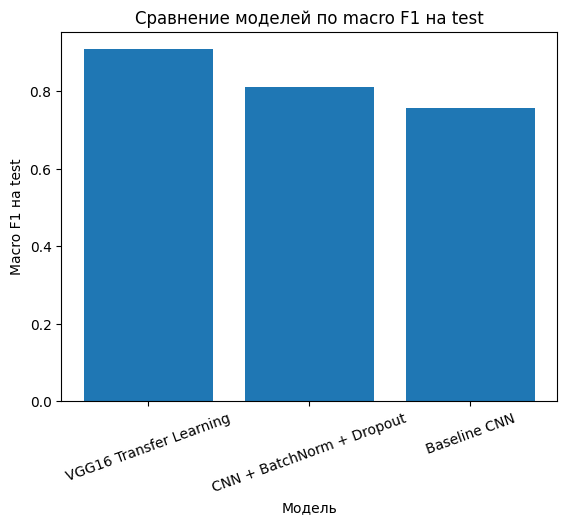

In [ ]:
plt.bar(model_results["model"], model_results["test_macro_f1"])
plt.title("Сравнение моделей по macro F1 на test")
plt.xlabel("Модель")
plt.ylabel("Macro F1 на test")
plt.xticks(rotation=20)
plt.show()


In [ ]:
result_by_name = {
    baseline_result["model"]: baseline_result,
    bn_result["model"]: bn_result,
    vgg_result["model"]: vgg_result
}
best_model_name = model_results.iloc[0]["model"]
best_result = result_by_name[best_model_name]
print("Лучшая модель:", best_model_name)
print()
print("Отчёт по качеству классификации для лучшей модели:")
print(classification_report(
    best_result["test_labels"],
    best_result["test_preds"],
    target_names=train_dataset.classes,
    zero_division=0,
    digits=4
))

Лучшая модель: VGG16 Transfer Learning

Отчёт по качеству классификации для лучшей модели:
               precision    recall  f1-score   support

        crack     0.9273    0.7286    0.8160        70
         dent     0.8756    0.8051    0.8389       236
glass_shatter     0.9595    1.0000    0.9793        71
  lamp_broken     0.9848    0.9420    0.9630        69
      scratch     0.8235    0.9121    0.8655       307
    tire_flat     0.9697    1.0000    0.9846        32

     accuracy                         0.8777       785
    macro avg     0.9234    0.8980    0.9079       785
 weighted avg     0.8809    0.8777    0.8768       785



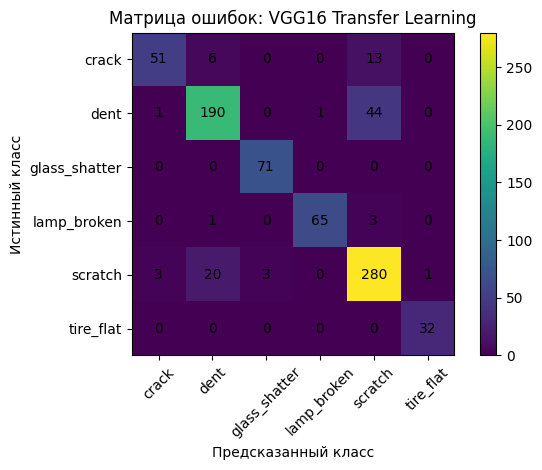

In [ ]:
cm = confusion_matrix(
    best_result["test_labels"],
    best_result["test_preds"]
)
plt.imshow(cm)
plt.title(f"Матрица ошибок: {best_model_name}")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks(np.arange(len(train_dataset.classes)), train_dataset.classes, rotation=45)
plt.yticks(np.arange(len(train_dataset.classes)), train_dataset.classes)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
if USE_WANDB:
    wandb.init(
        project=PROJECT_NAME,
        name="model_comparison_report",
        job_type="reporting"
    )
    artifact = wandb.Artifact(
        name="model_comparison_results",
        type="results",
        description="Final comparison table for CarDD classification models"
    )
    artifact.add_file(str(comparison_path))
    wandb.log_artifact(artifact)
    for row in model_results.itertuples():
        prefix = row.model.lower().replace(" ", "_").replace("+", "plus")
        wandb.log({
            f"{prefix}_best_val_accuracy": row.best_val_accuracy,
            f"{prefix}_test_accuracy": row.test_accuracy,
            f"{prefix}_test_macro_f1": row.test_macro_f1,
            f"{prefix}_test_weighted_f1": row.test_weighted_f1
        })
    wandb.finish()

wandb: WARNING Artifact "model_comparison_results" already exists with the same content. No new version will be created.


baseline_cnn_best_val_accuracy,▁
baseline_cnn_test_accuracy,▁
baseline_cnn_test_macro_f1,▁
baseline_cnn_test_weighted_f1,▁
cnn_plus_batchnorm_plus_dropout_best_val_accuracy,▁
cnn_plus_batchnorm_plus_dropout_test_accuracy,▁
cnn_plus_batchnorm_plus_dropout_test_macro_f1,▁
cnn_plus_batchnorm_plus_dropout_test_weighted_f1,▁
vgg16_transfer_learning_best_val_accuracy,▁
vgg16_transfer_learning_test_accuracy,▁
+2,...


In [ ]:
best_row = model_results.iloc[0]
print(
    f"Итог: лучшая модель - {best_row['model']}"
    f"На test-выборке получилась accuracy = {best_row['test_accuracy']:.4f}"
    f"macro F1 = {best_row['test_macro_f1']:.4f}"
    f"weighted F1 = {best_row['test_weighted_f1']:.4f}"
)

Итог: лучшая модель - VGG16 Transfer Learning. На test-выборке она получила accuracy = 0.8777, macro F1 = 0.9079, weighted F1 = 0.8768.
